<a href="https://colab.research.google.com/github/fabiocf12/MPA-MLF-exercises/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten,BatchNormalization,Dropout
from keras.optimizers import SGD,Adam
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.regularizers import l2
from keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import cv2

font = {'weight' : 'bold',
        'size'   : 12}

matplotlib.rc('font', **font)


In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
labels = {0:'airplane',1:'automobile',2:'bird',3:'cat',4:'deer',5:'dog',6:'frog',7:'horse',8:'ship',9:'truck'}

In [ ]:
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels_encoded = y_data[selected_ind]
  selected_labels = [labels[x[0]] for x in selected_labels_encoded]

  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img)

  for id_label, label in enumerate(selected_labels):
    plt.text((32/2) + 32*id_label - len(label), 32*(5/4), label)
  plt.axis('off')
  plt.show()

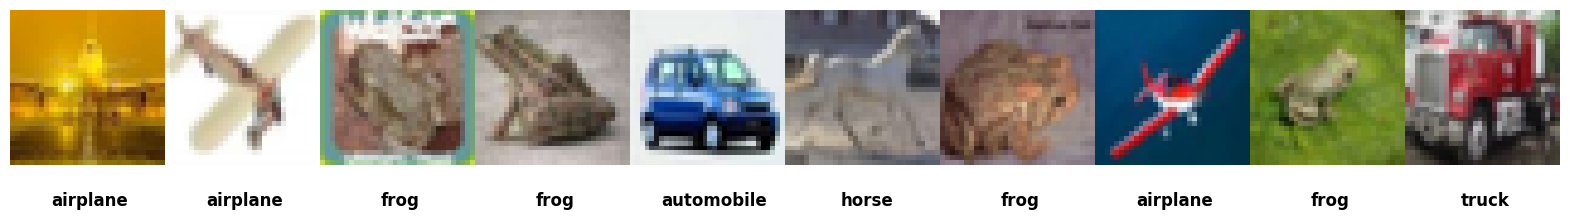

In [ ]:
display_random_images(X_train, y_train)

In [ ]:
X_train.shape

(50000, 32, 32, 3)

In [ ]:
def display_channels_separately(image: np.array) -> None:

  plt.figure()
  fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(10, 5))


  axs[0].imshow(image[:,:,0],cmap='Reds')
  axs[1].imshow(image[:,:,1],cmap='Blues')
  axs[2].imshow(image[:,:,2],cmap='Greens')

  axs[3].imshow(image)

  plt.show()

<Figure size 640x480 with 0 Axes>

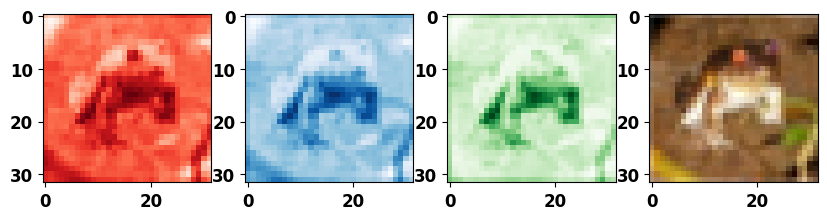

In [ ]:
display_channels_separately(X_train[0])

In [ ]:
X_train_scaled = X_train.astype('float32') / 255.0

In [ ]:
y_train_encoded = to_categorical(y_train, num_classes=10)

In [ ]:
model = Sequential()

#convert the 2D image data into a 1D vector
model.add(Flatten(input_shape=(32, 32, 3)))


model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))


model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))


model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# output
model.add(Dense(10, activation='softmax'))

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,812,618 (14.54 MB)

 Trainable params: 3,809,034 (14.53 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [ ]:
optimizer = Adam(learning_rate=0.0005)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

In [ ]:
history = model.fit(X_train_scaled, y_train_encoded, epochs=50, batch_size=128, validation_split = 0.2,callbacks=[early_stop])

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 110ms/step - accuracy: 0.3054 - loss: 2.1000 - val_accuracy: 0.3386 - val_loss: 1.8514
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.3720 - loss: 1.7992 - val_accuracy: 0.3691 - val_loss: 1.7892
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.4038 - loss: 1.6846 - val_accuracy: 0.3970 - val_loss: 1.6925
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.4209 - loss: 1.6255 - val_accuracy: 0.4087 - val_loss: 1.6691
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - accuracy: 0.4368 - loss: 1.5820 - val_accuracy: 0.3743 - val_loss: 1.7299
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - accuracy: 0.4444 - loss: 1.5481 - val_accuracy: 0.4203 - val_loss: 1.6166
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.4521 - loss: 1.5284 - val_accuracy: 0.3786 - val_loss: 1.7434
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.4570 - loss: 1

In [ ]:
#6. Model evaluation
X_test = X_test.astype('float32') / 255.0
y_test_encoded = to_categorical(y_test, num_classes=10)

In [ ]:
score = model.evaluate(X_test, y_test_encoded, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: {score[1]*100} %')

Test loss: 1.3566228151321411
Test accuracy: 51.9599974155426 %


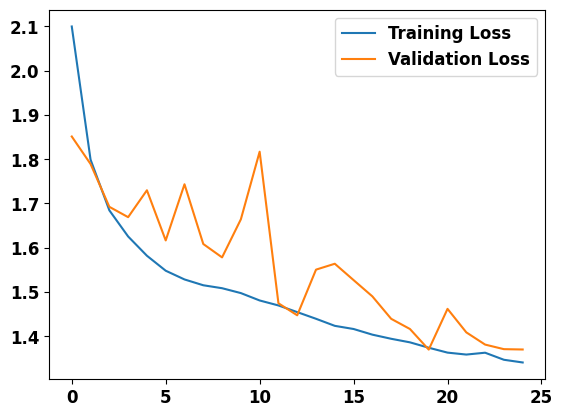

In [ ]:
plt.figure()
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.legend()


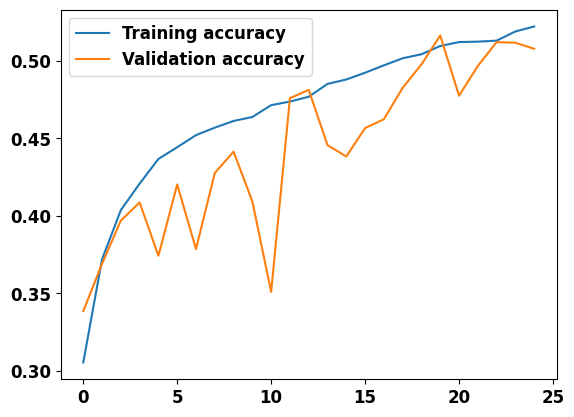

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'],label='Training accuracy')
plt.plot(history.history['val_accuracy'],label='Validation accuracy')

plt.legend()


In [ ]:
def show_the_best_predictions(model, x_test: np.array, y_test: np.array, n_of_pred: int = 10) -> None:
  mapping = {0:'airplane',1:'automobile',2:'bird',3:'cat',4:'deer',5:'dog',6:'frog',7:'horse',8:'ship',9:'truck'}

  predictions = model.predict(x_test)
  y_test = y_test.reshape(1,-1)
  predictions_ind = np.argmax(predictions, axis=1)
  predictions_ind = predictions_ind.reshape(1, -1)

  corect_predictions = np.where(predictions_ind == y_test)

  rows_correct = corect_predictions[1]
  predictedtions_correct = predictions[rows_correct]
  target_correct = y_test[0][rows_correct]

  max_samples = predictions[rows_correct, target_correct]
  selected_images = x_test[rows_correct]
  sorted_ind = np.argsort(max_samples)[::-1]


  images = []
  prob = []
  labels = []


  for ind in range(n_of_pred):

    index = sorted_ind[ind]

    labels.append(target_correct[index])
    prob.append(max_samples[index])
    images.append(selected_images[index])

  plt.figure(figsize=(20,10))

  images = np.concatenate(np.asarray(images),axis=1)
  plt.imshow(images)
  for ins in range(n_of_pred):
    texts = '{}: \n{:.3f} %'.format(mapping[labels[ins]], prob[ins]*100)
    plt.text((32/2) + 32*ins - len(mapping[labels[ins]]), 32*(5/4), texts)

  plt.axis('off')
  plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


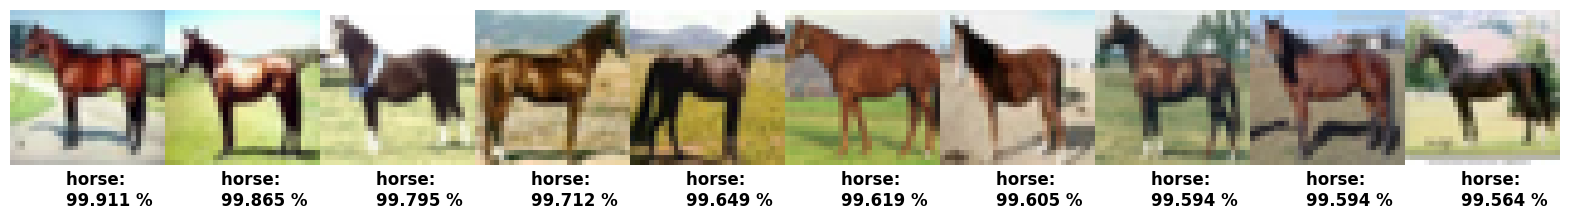

In [ ]:
show_the_best_predictions(model, X_test, y_test)

# TASK DESCRIPTION

The key modifications include:

  Epochs: Increased the maximum number of epochs from 20 to 50 to give the network more time to learn.
  
  Activation Function: Changed from Sigmoid to ReLU in the hidden layers to mitigate the vanishing gradient problem and accelerate learning.

  Optimizer: Switched from SGD to Adam.

  Model Capacity: Increased the depth and width of the network (e.g., using layers with 1024, 512, and 256 neurons) to allow the model to learn more complex patterns from the flattened 3072-pixel input.

  Regularization (Dropout & Batch Normalization): Added BatchNormalization to stabilize the outputs between layers, and Dropout (0.3) to randomly deactivate neurons. This successfully prevented the model from memorizing the training data (overfitting).

  Callbacks (Early Stopping ): Implemented EarlyStopping to halt training when the val_loss stopped improving, saving computational resources.

In [24]:
# Random search for hyperparameter tunning

import random
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.optimizers import Adam

learning_rates = [0.001, 0.0005, 0.0001]
dropouts = [0.1, 0.2, 0.3, 0.4]

best_accuracy = 0
best_config = {}

print("Initiating Random Search...\n")

for i in range(3):
  lr_test = random.choice(learning_rates)
  drop_test = random.choice(dropouts)

  print(f"\n--- Test {i+1}/3: Testing LR={lr_test} / Dropout={drop_test} ---")

  model_rs = Sequential()

  model_rs.add(Flatten(input_shape=(32, 32, 3)))

  model_rs.add(Dense(1024, activation='relu'))
  model_rs.add(Dropout(drop_test))

  model_rs.add(Dense(512, activation='relu'))
  model_rs.add(Dropout(drop_test))

  model_rs.add(Dense(256, activation='relu'))
  model_rs.add(Dropout(drop_test))

  #output
  model_rs.add(Dense(10, activation='softmax'))

  optimizer_rs = Adam(learning_rate=lr_test)
  model_rs.compile(loss='categorical_crossentropy', optimizer=optimizer_rs, metrics=['accuracy'])

  history = model_rs.fit(X_train_scaled, y_train_encoded, epochs=5, batch_size=128, validation_split=0.2)

  score = model_rs.evaluate(X_test, y_test_encoded, verbose=0)
  print('Test loss:', score[0])
  print(f'Test accuracy: {score[1]*100} %')



  if score[1]*100 > best_accuracy:
      best_accuracy = score[1]*100
      best_config = {'LR': lr_test, 'Dropout': drop_test}

# 3. Winner
print(f"\n\nBest accuracy found: {best_accuracy:.2f}%")
print(f"Best Config : Learning Rate = {best_config['LR']}, Dropout = {best_config['Dropout']}")

Initiating Random Search...


--- Test 1/3: Testing LR=0.0005 / Dropout=0.2 ---
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - accuracy: 0.2704 - loss: 1.9911 - val_accuracy: 0.3352 - val_loss: 1.8334
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - accuracy: 0.3455 - loss: 1.8047 - val_accuracy: 0.3848 - val_loss: 1.7254
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.3692 - loss: 1.7453 - val_accuracy: 0.4027 - val_loss: 1.6748
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - accuracy: 0.3934 - loss: 1.6904 - val_accuracy: 0.4216 - val_loss: 1.6336
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.4074 - loss: 1.6486 - val_accuracy: 0.4313 - val_loss: 1.5991
Test loss: 1.5710461139678955
Test accuracy: 44.01000142097473 %

--- Test 2/3: Testing LR=0.0001 / Dropout=0.4 ---
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 122ms/step - accuracy: 0.2038 - loss: 2.1453 - val_accuracy: 0.3184 - val_loss: 1.9288
Epoch 2/5
313/313 ━━━━━━